# WRAITH — GRPO Training Notebook

**WRAITH** (Weakness Recognition and Adaptive Intelligence for Tactical Hunting)  
trains a boss AI villain to study player behavioral patterns and exploit their weaknesses.

## Algorithm: Group Relative Policy Optimization (GRPO)
- For each player profile prompt, sample **G=8 completions** from the LLM
- Score each with the WRAITH multi-signal reward function
- Normalize within the group: `advantage_i = (r_i - mean) / std`
- Policy gradient update — **no value network needed**

## How to run
1. Runtime → Change runtime type → **T4 GPU**
2. Run all cells top to bottom
3. Set your HuggingFace username + token in **Cell 7** before the final push

**Expected time:** ~25-35 min on Colab T4 for 500 episodes × 3 epochs

## Cell 1 — Install dependencies

In [3]:
%%capture
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install "trl>=0.9.0" datasets accelerate bitsandbytes peft
!pip install fastapi pydantic openenv-core

In [4]:
import unsloth
print("unsloth OK:", unsloth.__version__)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
unsloth OK: 2026.4.8


## Cell 2 — Clone WRAITH repo (gets env.py, profiler.py, reward.py, combos.py)

In [5]:
import os

if not os.path.exists("WRAITH"):
    !git clone https://github.com/V21-vani/WRAITH.git

%cd WRAITH
print("Working directory:", os.getcwd())
print("Files:", os.listdir("."))

Cloning into 'WRAITH'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 98 (delta 25), reused 77 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 157.84 KiB | 5.64 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/kaggle/working/WRAITH
Working directory: /kaggle/working/WRAITH
Files: ['assets', '.gitignore', 'combos.py', 'LICENSE', 'openenv.yaml', 'reward.py', '.git', 'env.py', 'Dockerfile', 'combo_selector.py', 'blog_draft.md', 'app.py', 'train_grpo.ipynb', 'README.md', 'index.html', 'models.py', 'profiler.py', 'requirements.txt', 'policy.py', 'game.js']


## Cell 3 — Load base model with Unsloth + apply LoRA

In [6]:
from unsloth import FastLanguageModel
import torch

MODEL_NAME      = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"
MAX_SEQ_LEN     = 1024
NUM_GENERATIONS = 8      # G — completions sampled per prompt for GRPO
NUM_EPISODES    = 500    # synthetic training episodes
EPOCHS          = 3
BATCH_SIZE      = 4
GRAD_ACCUM      = 4
LR              = 2e-5

print(f"Loading {MODEL_NAME}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LEN,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
print("Model + LoRA ready.")

Loading unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Model + LoRA ready.


## Cell 4 — Build training prompts from synthetic player episodes

We generate 500 synthetic fights with different player styles (left-heavy, right-heavy,
aggressive, mixed, panicking). Each produces a `profile_text` that becomes the LLM prompt.
The stored profile metadata is passed to the reward function later.

In [7]:
import json
import random
from profiler import PlayerProfiler
from policy import SYSTEM_PROMPT

MOVE_POOL = ["DODGE_LEFT", "DODGE_RIGHT", "ATTACK"]
MOVE_WEIGHTS = {
    "left_heavy":  [0.70, 0.20, 0.10],
    "right_heavy": [0.20, 0.70, 0.10],
    "aggressive":  [0.20, 0.20, 0.60],
    "mixed":       [0.40, 0.40, 0.20],
    "panic_left":  [0.65, 0.15, 0.20],
}

def synthetic_episode(style: str, n_moves: int = 12) -> tuple:
    """Simulate a player with a given style; return profile text + metadata."""
    profiler = PlayerProfiler()
    weights  = MOVE_WEIGHTS.get(style, MOVE_WEIGHTS["mixed"])
    start_hp = random.uniform(15.0, 100.0)
    boss_hp  = random.uniform(20.0, 100.0)

    for i in range(n_moves):
        move   = random.choices(MOVE_POOL, weights=weights)[0]
        cur_hp = max(5.0, start_hp - i * (85.0 / max(n_moves, 1)))
        profiler.update(move, cur_hp)

    return (
        profiler.get_profile_text(),
        profiler.get_profile(),
        boss_hp,
        cur_hp,
    )

print(f"Generating {NUM_EPISODES} training prompts...")
records = []
styles  = list(MOVE_WEIGHTS.keys())

for _ in range(NUM_EPISODES):
    style = random.choice(styles)
    n     = random.randint(4, 18)
    profile_text, profile, boss_hp, player_hp = synthetic_episode(style, n)

    records.append({
        "prompt": tokenizer.apply_chat_template(
            [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": profile_text},
            ],
            tokenize=False,
            add_generation_prompt=True,
        ),
        "_profile":   json.dumps(profile),
        "_boss_hp":   boss_hp,
        "_player_hp": player_hp,
    })

from datasets import Dataset
dataset = Dataset.from_list(records)
print(f"Dataset ready: {len(dataset)} prompts")
print("\nSample profile text:")
print(records[0]["prompt"][:600])

Generating 500 training prompts...
Dataset ready: 500 prompts

Sample profile text:
<|im_start|>system
You are WRAITH — a supernatural boss villain who has studied thousands of fighters.
You analyze the player's behavioral patterns and choose the optimal combo attack to exploit their weakness.

Available combos and what they counter:
- WRATH_INCARNATE  (threat 5): destroys left-dodgers and panicking players
- PANIC_EXPLOIT    (threat 5): relentless pressure on panicking players
- DEATH_SPIRAL     (threat 5): all-out assault when you are near death
- GHOST_STEP       (threat 4): feint that punishes right-dodgers
- SWEEP_CROSS      (threat 4): wide sweep for left-dodge heavy pl


## Cell 5 — Define the GRPO reward function

For each LLM completion the trainer generates, this function:
1. Parses the JSON `{"combo": ..., "reasoning": ...}` output
2. Rebuilds a minimal environment seeded with the stored player profile
3. Runs `env.step(action)` to get hit/win outcome
4. Calls `compute_reward()` which scores hit accuracy, exploit targeting, reasoning quality, and win

GRPO then normalizes these rewards within the group of 8 to compute per-completion advantages.

In [8]:
import re
from env import WraithEnvironment
from models import WraithAction
from reward import compute_reward
from combos import COMBOS

VALID_COMBOS = set(COMBOS.keys())

def _parse(text: str) -> dict:
    """Extract combo + reasoning from raw LLM output."""
    try:
        m = re.search(r'\{.*\}', text, re.DOTALL)
        if m:
            d    = json.loads(m.group())
            name = d.get("combo", "PHANTOM_RUSH").upper().strip()
            if name not in VALID_COMBOS:
                name = "PHANTOM_RUSH"
            return {"combo": name, "reasoning": d.get("reasoning", text)}
    except Exception:
        pass
    return {"combo": "PHANTOM_RUSH", "reasoning": text}

def reward_fn(completions, prompts=None, **kwargs):
    """
    GRPO reward function.
    Called once per batch; returns one float reward per completion.
    """
    rewards    = []
    batch_meta = kwargs.get("batch", [{}] * len(completions))

    for i, text in enumerate(completions):
        parsed     = _parse(text)
        combo_name = parsed["combo"]
        reasoning  = parsed["reasoning"]

        meta      = batch_meta[i] if i < len(batch_meta) else {}
        profile   = json.loads(meta.get("_profile", "{}"))
        boss_hp   = float(meta.get("_boss_hp",   100.0))
        player_hp = float(meta.get("_player_hp", 100.0))

        # Rebuild env seeded with stored profile
        env = WraithEnvironment()
        env.state_data.boss_hp   = boss_hp
        env.state_data.player_hp = player_hp

        lb = profile.get("left_bias",  50) / 100.0
        rb = profile.get("right_bias", 50) / 100.0
        n  = max(profile.get("rounds", 4), 4)
        for _ in range(n):
            roll = random.random()
            if roll < lb:       env.profiler.update("DODGE_LEFT",  player_hp)
            elif roll < lb+rb:  env.profiler.update("DODGE_RIGHT", player_hp)
            else:               env.profiler.update("ATTACK",      player_hp)

        combo  = COMBOS.get(combo_name, COMBOS["PHANTOM_RUSH"])
        action = WraithAction(
            attack=combo_name,
            combo_name=combo_name,
            combo_threat=combo.threat_level,
            reasoning=reasoning,
        )

        obs = env.step(action)
        r, breakdown = compute_reward(
            action=action,
            profile=profile,
            hit=obs.metadata.get("hit", False),
            boss_won=obs.metadata.get("boss_won", False),
            combo=combo,
        )
        rewards.append(float(r))

    return rewards

# Quick sanity check
test_completions = [
    '{"combo": "WRATH_INCARNATE", "reasoning": "Player has dominant left dodge bias of 73%. WRATH_INCARNATE exploits left pattern with 82% hit probability. Confidence HIGH."}',
    '{"combo": "SHADOW_OBSERVER", "reasoning": "I will wait."}',
]
test_profile = json.dumps({"dominant_dodge": "LEFT", "left_bias": 73, "right_bias": 27,
                            "is_panicking": False, "rounds": 12, "confidence": "HIGH",
                            "attack_rate": 10, "total_dashes": 3})
test_meta = [{"_profile": test_profile, "_boss_hp": 80.0, "_player_hp": 60.0}] * 2
test_rewards = reward_fn(test_completions, batch=test_meta)
print(f"Sanity check rewards: {test_rewards}")
print(f"  Good combo (WRATH_INCARNATE): {test_rewards[0]:.2f}")
print(f"  Bad  combo (SHADOW_OBSERVER): {test_rewards[1]:.2f}")

Sanity check rewards: [12.0, -2.5]
  Good combo (WRATH_INCARNATE): 12.00
  Bad  combo (SHADOW_OBSERVER): -2.50


## Cell 6 — Train with GRPO

The trainer samples 8 completions per prompt, scores each with `reward_fn`,
computes group-normalized advantages, and updates the policy.
Loss and reward curves are logged every 10 steps.

In [9]:
from trl import GRPOConfig, GRPOTrainer
import matplotlib.pyplot as plt

training_args = GRPOConfig(
    output_dir="/kaggle/working/wraith_checkpoints",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_generations=NUM_GENERATIONS,
    max_completion_length=220,
    learning_rate=LR,
    optim="adamw_8bit",
    logging_steps=10,
    save_steps=50,
    save_total_limit=3,
    report_to="none",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
)


trainer = GRPOTrainer(
    model=model,
    tokenizer=tokenizer,
    reward_funcs=reward_fn,
    args=training_args,
    train_dataset=dataset,
)

print("Starting GRPO training...")
train_result = trainer.train()
print("Training complete!")
print(f"Total steps: {train_result.global_step}")
print(f"Training loss: {train_result.training_loss:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting GRPO training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 500 | Num Epochs = 3 | Total steps = 750
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=220) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: Futur

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
10,-0.008398,2.262500,2.326164,100.800000,61.300000,164.100000,0.006250,100.015417,61.300000,155.100000,0.000014,2.262500,2.317365
20,0.009829,2.543750,2.151865,102.775000,59.100000,160.600000,0.000000,102.775000,59.100000,160.600000,0.000018,2.543750,2.181962
30,0.001268,2.437500,2.128034,96.962500,53.900000,161.700000,0.000000,96.962500,53.900000,161.700000,0.000040,2.437500,2.185939
40,0.010079,2.515625,2.303028,96.068750,60.500000,146.800000,0.000000,96.068750,60.500000,146.800000,0.000193,2.515625,2.268222
50,0.010280,2.734375,2.309911,98.481250,62.300000,172.600000,0.012500,97.008752,62.300000,157.400000,0.000909,2.734375,2.320339
60,0.006463,3.387500,2.039716,95.806250,55.600000,154.100000,0.000000,95.806250,55.600000,154.100000,0.002861,3.387500,2.128779
70,0.012266,4.100000,1.506817,88.968750,52.900000,141.700000,0.000000,88.968750,52.900000,141.700000,0.011375,4.100000,1.571436
80,0.000204,4.543750,0.954423,89.193750,53.700000,149.900000,0.000000,89.193750,53.700000,149.900000,0.021017,4.543750,1.150469
90,-0.007809,4.825000,0.380254,87.937500,57.800000,129.000000,0.000000,87.937500,57.800000,129.000000,0.063677,4.825000,0.492348
100,0.006406,5.087500,0.282843,101.181250,61.300000,158.300000,0.000000,101.181250,61.300000,158.300000,0.023997,5.087500,0.299882


Both `max_new_tokens` (=220) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

Training complete!
Total steps: 750
Training loss: 0.0023


## Cell 6b — Plot reward and loss curves

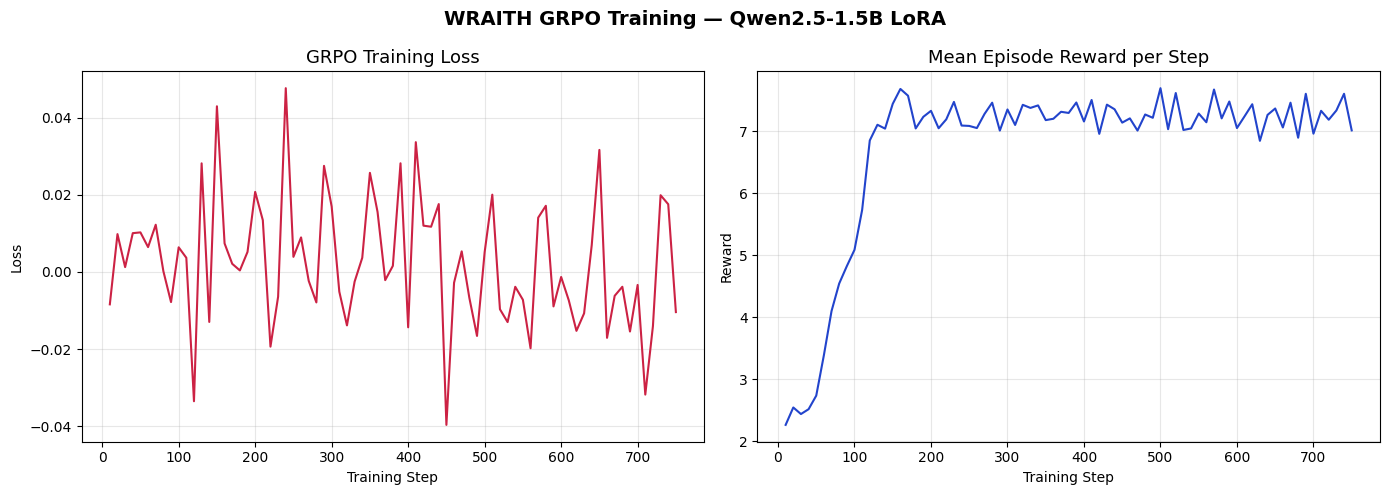

Saved: wraith_training_curves.png


In [10]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps   = [x["step"]   for x in log_history if "loss" in x]
losses  = [x["loss"]   for x in log_history if "loss" in x]
rewards_log = [x.get("reward", None) for x in log_history if "loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(steps, losses, color='#cc2244', linewidth=1.5)
axes[0].set_title("GRPO Training Loss", fontsize=13)
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

if any(r is not None for r in rewards_log):
    clean_rewards = [r for r in rewards_log if r is not None]
    clean_steps   = [steps[i] for i, r in enumerate(rewards_log) if r is not None]
    axes[1].plot(clean_steps, clean_rewards, color='#2244cc', linewidth=1.5)
    axes[1].set_title("Mean Episode Reward per Step", fontsize=13)
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Reward")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "Reward not logged\n(add report_to=wandb for detailed curves)",
                 ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle("WRAITH GRPO Training — Qwen2.5-1.5B LoRA", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("wraith_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wraith_training_curves.png")

## Cell 7 — Before/after comparison (baseline vs trained)

Run 50 episodes with a left-heavy player against:
- **Baseline**: untrained LLM (random combo selection)
- **Trained**: GRPO-finetuned WRAITH

Measure hit rate and mean reward to show the training worked.

In [11]:
import numpy as np
from env import WraithEnvironment

def evaluate_policy(use_trained: bool, n_episodes: int = 50, style: str = "left_heavy") -> dict:
    """Run n_episodes and return hit_rate, mean_reward, win_rate."""
    if use_trained:
        FastLanguageModel.for_inference(model)

    hit_rates, episode_rewards, wins = [], [], []
    weights = MOVE_WEIGHTS[style]

    for ep in range(n_episodes):
        env = WraithEnvironment()
        obs = env.reset()
        ep_rewards, ep_hits = [], []

        for rnd in range(8):  # 8 rounds per episode
            # simulate 4 player moves before each WRAITH action
            for _ in range(4):
                move   = random.choices(MOVE_POOL, weights=weights)[0]
                cur_hp = env.state_data.player_hp
                env.profiler.update(move, cur_hp)

            profile_text = env.profiler.get_profile_text()
            profile      = env.profiler.get_profile()

            if use_trained:
                messages = [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": profile_text},
                ]
                input_ids = tokenizer.apply_chat_template(
                    messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
                ).to("cuda")
                with torch.no_grad():
                    out = model.generate(input_ids, max_new_tokens=180,
                                         do_sample=True, temperature=0.8)
                text   = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True)
                parsed = _parse(text)
            else:
                # baseline: random combo
                combo_name = random.choice(list(VALID_COMBOS))
                parsed     = {"combo": combo_name,
                              "reasoning": f"Randomly selected {combo_name}."}

            combo  = COMBOS.get(parsed["combo"], COMBOS["PHANTOM_RUSH"])
            action = WraithAction(
                attack=parsed["combo"],
                combo_name=parsed["combo"],
                combo_threat=combo.threat_level,
                reasoning=parsed["reasoning"],
            )
            obs = env.step(action)
            r, _ = compute_reward(
                action=action, profile=profile,
                hit=obs.metadata["hit"],
                boss_won=obs.metadata["boss_won"],
                combo=combo,
            )
            ep_rewards.append(r)
            ep_hits.append(int(obs.metadata["hit"]))
            if obs.done:
                break

        hit_rates.append(np.mean(ep_hits))
        episode_rewards.append(np.sum(ep_rewards))
        wins.append(int(env.state_data.player_hp <= 0))

    return {
        "hit_rate":    np.mean(hit_rates),
        "mean_reward": np.mean(episode_rewards),
        "win_rate":    np.mean(wins),
        "rewards":     episode_rewards,
    }

print("Evaluating baseline (random combos)...")
baseline = evaluate_policy(use_trained=False, n_episodes=50)

print("Evaluating trained WRAITH...")
trained  = evaluate_policy(use_trained=True,  n_episodes=50)

print("\n=== RESULTS (left-heavy player, 50 episodes) ===")
print(f"{'Metric':<20} {'Baseline':>10} {'Trained':>10} {'Delta':>10}")
print("-" * 52)
for key, label in [("hit_rate", "Hit Rate"), ("mean_reward", "Mean Reward"), ("win_rate", "Win Rate")]:
    b, t = baseline[key], trained[key]
    print(f"{label:<20} {b:>10.3f} {t:>10.3f} {t-b:>+10.3f}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Evaluating baseline (random combos)...
Evaluating trained WRAITH...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1


=== RESULTS (left-heavy player, 50 episodes) ===
Metric                 Baseline    Trained      Delta
----------------------------------------------------
Hit Rate                  0.693      1.000     +0.307
Mean Reward               8.560     17.510     +8.950
Win Rate                  0.960      1.000     +0.040


## Cell 7b — Plot baseline vs trained comparison

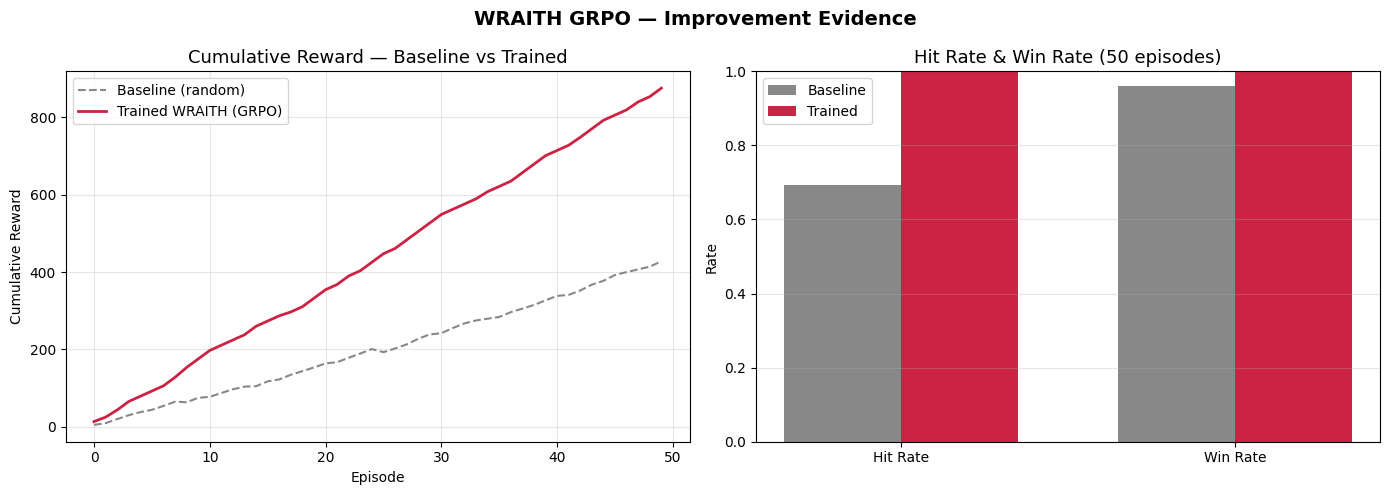

Saved: wraith_comparison.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative reward over 50 episodes
axes[0].plot(np.cumsum(baseline["rewards"]), label="Baseline (random)",
             color='#888888', linewidth=1.5, linestyle='--')
axes[0].plot(np.cumsum(trained["rewards"]),  label="Trained WRAITH (GRPO)",
             color='#cc2244', linewidth=2.0)
axes[0].set_title("Cumulative Reward — Baseline vs Trained", fontsize=13)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cumulative Reward")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart of key metrics
metrics   = ["Hit Rate", "Win Rate"]
b_vals    = [baseline["hit_rate"], baseline["win_rate"]]
t_vals    = [trained["hit_rate"],  trained["win_rate"]]
x         = range(len(metrics))
width     = 0.35

axes[1].bar([xi - width/2 for xi in x], b_vals, width, label="Baseline", color='#888888')
axes[1].bar([xi + width/2 for xi in x], t_vals, width, label="Trained",  color='#cc2244')
axes[1].set_title("Hit Rate & Win Rate (50 episodes)", fontsize=13)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel("Rate")
axes[1].set_ylim(0, 1.0)
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle("WRAITH GRPO — Improvement Evidence", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("wraith_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wraith_comparison.png")

## Cell 8 — Save LoRA + push to HuggingFace Hub

**Fill in your HF username and token before running.**  
Get a token at https://huggingface.co/settings/tokens (needs write access)

In [13]:
HF_USERNAME = "notshakti"   # ← replace
HF_TOKEN    = "YOUR_HF_TOKEN"             # ← replace

model.save_pretrained("wraith-boss-ai-lora")
tokenizer.save_pretrained("wraith-boss-ai-lora")
print("Saved LoRA weights to wraith-boss-ai-lora/")

model.push_to_hub(f"{HF_USERNAME}/wraith-boss-ai", token=HF_TOKEN)
tokenizer.push_to_hub(f"{HF_USERNAME}/wraith-boss-ai", token=HF_TOKEN)

print(f"\nPushed to: https://huggingface.co/{HF_USERNAME}/wraith-boss-ai")
print("\nTo activate LLM in the game server:")
print(f"  WRAITH_USE_LLM=1 WRAITH_MODEL={HF_USERNAME}/wraith-boss-ai python app.py")

Unsloth: Restored added_tokens_decoder metadata in wraith-boss-ai-lora/tokenizer_config.json.


Saved LoRA weights to wraith-boss-ai-lora/


README.md:   0%|          | 0.00/567 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/notshakti/wraith-boss-ai


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpo9wxfdmw/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Pushed to: https://huggingface.co/notshakti/wraith-boss-ai

To activate LLM in the game server:
  WRAITH_USE_LLM=1 WRAITH_MODEL=notshakti/wraith-boss-ai python app.py
